# This notebook contains the EDA of the financial fraud dataset from Kaggle

In [21]:
#%pip install -r ../requirements.txt -q

In [22]:
import kagglehub
import os
import shutil

# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw", exist_ok=True)

path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")
print("Dataset downloaded to:", path)

target_dir = "../data/raw/financial-fraud-detection-dataset"
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
shutil.copytree(path, target_dir)
print(f"Dataset copied to: {target_dir}")

path = target_dir

Dataset downloaded to: /Users/angjiayi/.cache/kagglehub/datasets/sriharshaeedala/financial-fraud-detection-dataset/versions/1
Dataset copied to: ../data/raw/financial-fraud-detection-dataset
Dataset copied to: ../data/raw/financial-fraud-detection-dataset


In [23]:
import pandas as pd
import os

csv_file = os.path.join(path, "Synthetic_Financial_datasets_log.csv")
print(f"Looking for file at: {csv_file}")


df = pd.read_csv(csv_file)
print("Shape:", df.shape)
print(df.head())
print(df.info())


Looking for file at: ../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv
Shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        

In [24]:
# checking the missing values in the data
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [25]:
# Check for duplicates
duplicates = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicates.shape[0]}")

# Check for conditional duplicates
dup_subset = df[df.duplicated(subset=['nameOrig', 'nameDest', 'type'], keep=False)]
print(f"Potential duplicate transactions (same sender, receiver, type): {dup_subset.shape[0]}")

dup_subset = df[df.duplicated(subset=['nameOrig', 'nameDest'], keep=False)]
print(f"Potential duplicate transactions (same sender, receiver): {dup_subset.shape[0]}")


Number of duplicate rows: 0
Potential duplicate transactions (same sender, receiver, type): 0
Potential duplicate transactions (same sender, receiver, type): 0
Potential duplicate transactions (same sender, receiver): 0
Potential duplicate transactions (same sender, receiver): 0


Identify accounts appearing both as nameOrig and nameDest

In [26]:
senders = set(df['nameOrig'].unique())
receivers = set(df['nameDest'].unique())


overlap_accounts = senders.intersection(receivers)

print(f"Total unique senders: {len(senders)}")
print(f"Total unique receivers: {len(receivers)}")
print(f"Accounts appearing as both sender and receiver: {len(overlap_accounts)}")



suspicious_df = df[df['nameOrig'].isin(overlap_accounts) | df['nameDest'].isin(overlap_accounts)]

print(suspicious_df.head(10))

Total unique senders: 6353307
Total unique receivers: 2722362
Accounts appearing as both sender and receiver: 1769
      step      type     amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
559      1  TRANSFER  100588.80  C1636588948       18913.68            0.00   
571      1   PAYMENT    3316.21  C1626852381           0.00            0.00   
862      1  CASH_OUT  171757.76  C1673916398           0.00            0.00   
1262     1   CASH_IN   35492.20  C1540476618      444567.92       480060.12   
1307     1   CASH_IN   82564.24   C322830747     6739112.35      6821676.59   
1321     1   CASH_IN  170207.14  C1816468636     8335475.31      8505682.45   
3534     2     DEBIT    4390.62   C571251299       69336.00        64945.38   
5699     6     DEBIT    7821.80   C486965279       19353.00        11531.20   
7091     6   CASH_IN   88549.90  C2141744605     4320892.68      4409442.58   
8572     7   CASH_IN   35884.67  C1359875538     2335651.45      2371536.12   

         nameDe

In [27]:
# How many transactions involve overlapping accounts
total_txn = df.shape[0]
overlap_txn = suspicious_df.shape[0]
print(f"Percentage of transactions involving dual-role accounts: {(overlap_txn / total_txn) * 100:.2f}%")

# Fraud rate among overlapping accounts
fraud_overlap = suspicious_df['isFraud'].sum()
fraud_rate_overlap = fraud_overlap / suspicious_df.shape[0]
overall_fraud_rate = df['isFraud'].mean()

print(f"Fraud rate (overlap accounts): {fraud_rate_overlap:.4f}")
print(f"Overall fraud rate (entire dataset): {overall_fraud_rate:.4f}")

Percentage of transactions involving dual-role accounts: 0.24%
Fraud rate (overlap accounts): 0.0012
Overall fraud rate (entire dataset): 0.0013


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

1. Transaction type insights

Transaction type distribution:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud rate by type:
type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64
type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64


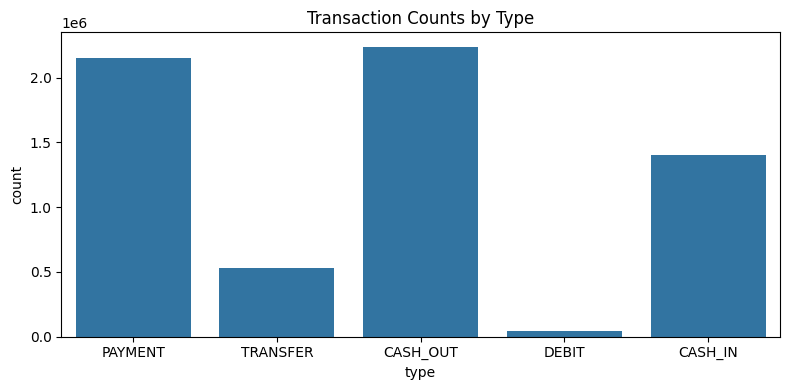

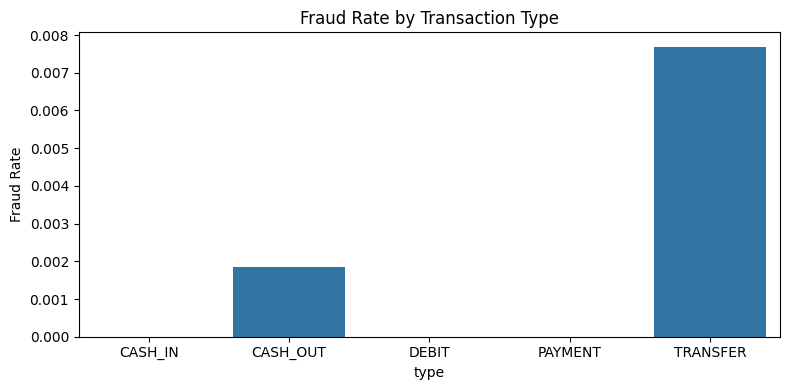

In [29]:

print("Transaction type distribution:")
print(df['type'].value_counts())
print("\nFraud rate by type:")
print(df.groupby('type')['isFraud'].mean())

plt.figure(figsize=(8,4))
sns.countplot(x='type', data=df)
plt.title("Transaction Counts by Type")
plt.tight_layout()
# Save to plots directory
plt.savefig('../plots/eda_transaction_type_counts.png')
plt.show()

plt.figure(figsize=(8,4))
fraud_rate_by_type = df.groupby('type')['isFraud'].mean()
sns.barplot(x=fraud_rate_by_type.index, y=fraud_rate_by_type.values)
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")
plt.tight_layout()
# Save to plots directory
plt.savefig('../plots/eda_fraud_rate_by_transaction_type.png')
plt.show()

2. Amount analysis

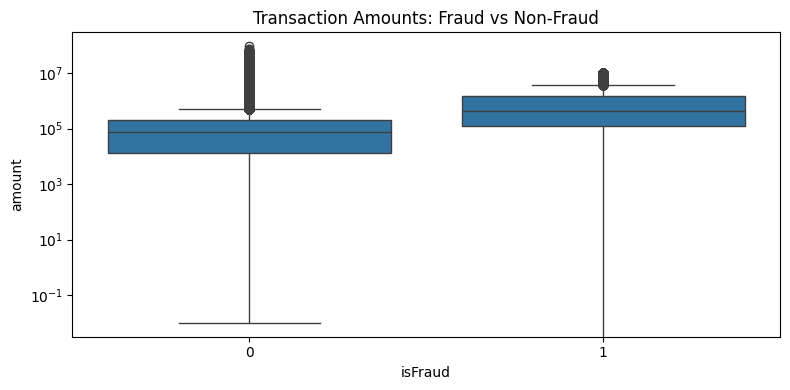


Amount summary (fraud vs non-fraud):
             count          mean           std   min         25%        50%  \
isFraud                                                                       
0        6354407.0  1.781970e+05  5.962370e+05  0.01   13368.395   74684.72   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.330  441423.44   

                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00  


In [30]:
plt.figure(figsize=(8,4))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')  # amounts vary a lot
plt.title("Transaction Amounts: Fraud vs Non-Fraud")
plt.tight_layout()
# Save to plots directory
plt.savefig('../plots/eda_transaction_amounts_fraud_vs_nonfraud.png')
plt.show()

print("\nAmount summary (fraud vs non-fraud):")
print(df.groupby('isFraud')['amount'].describe())

3. Temporal patterns (step)

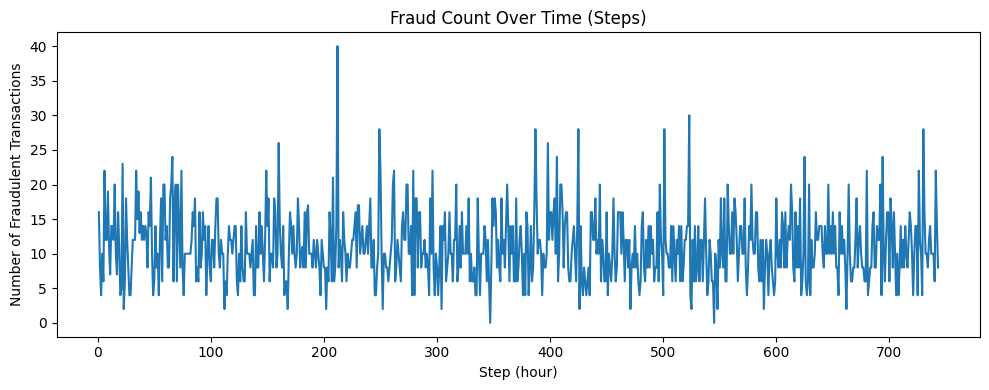

In [31]:
plt.figure(figsize=(10,4))
df.groupby('step')['isFraud'].sum().plot()
plt.title("Fraud Count Over Time (Steps)")
plt.xlabel("Step (hour)")
plt.ylabel("Number of Fraudulent Transactions")
plt.tight_layout()
# Save to plots directory
plt.savefig('../plots/eda_fraud_count_over_time_steps.png')
plt.show()

4. Sender / Receiver behavior


Transactions per sender (summary):
count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: count, dtype: float64

Top 10 senders by total amount:
nameOrig
C1715283297    92445516.64
C2127282686    73823490.36
C2044643633    71172480.42
C1425667947    69886731.30
C1584456031    69337316.27
C811810230     67500761.29
C420748282     66761272.21
C1139847449    64234448.19
C300140823     63847992.58
C372535854     63294839.63
Name: amount, dtype: float64

Top 10 senders by total amount:
nameOrig
C1715283297    92445516.64
C2127282686    73823490.36
C2044643633    71172480.42
C1425667947    69886731.30
C1584456031    69337316.27
C811810230     67500761.29
C420748282     66761272.21
C1139847449    64234448.19
C300140823     63847992.58
C372535854     63294839.63
Name: amount, dtype: float64


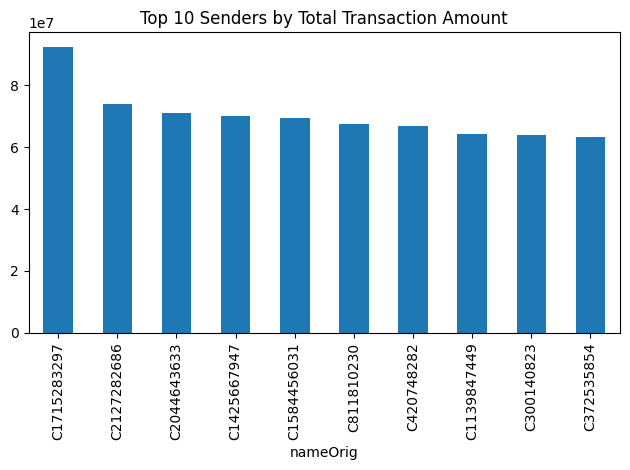

In [32]:
print("\nTransactions per sender (summary):")
print(df['nameOrig'].value_counts().describe())

top_senders = df.groupby('nameOrig')['amount'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 senders by total amount:")
print(top_senders)

top_senders.plot(kind='bar')
plt.title("Top 10 Senders by Total Transaction Amount")
plt.tight_layout()
# Save to plots directory
plt.savefig('../plots/eda_top10_senders_total_amount.png')
plt.show()

5. Fraud vs non-fraud ratio

In [33]:
fraud_ratio = df['isFraud'].value_counts(normalize=True)
print("\nFraud vs Non-Fraud ratio:")
print(fraud_ratio)


Fraud vs Non-Fraud ratio:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [34]:
# According to Kaggle dataset documentation, these features should be excluded for fraud analysis
cols_to_drop = ['nameOrig', 'nameDest', 'newbalanceOrig', 'oldbalanceOrg', 'newbalanceDest', 'oldbalanceDest']
df_encode = df.drop(columns=cols_to_drop)
print("Dropped columns:", cols_to_drop)
print("New shape:", df_encode.shape)
# Show all remaining columns
print(df_encode.columns)


Dropped columns: ['nameOrig', 'nameDest', 'newbalanceOrig', 'oldbalanceOrg', 'newbalanceDest', 'oldbalanceDest']
New shape: (6362620, 5)
Index(['step', 'type', 'amount', 'isFraud', 'isFlaggedFraud'], dtype='object')


In [35]:
# Encode 'type' column
df_encode['type'] = df_encode['type'].astype('category').cat.codes

# Correlation:

**Correlation** measures the linear relationship between two variables:
- Range: -1 to +1
- +1 = perfect positive correlation
- 0 = no linear relationship  
- -1 = perfect negative correlation
- Only considers **pairwise** relationships (low pairwise correlations == each pair look independent)

In [36]:
corr = df_encode.corr(numeric_only=True)

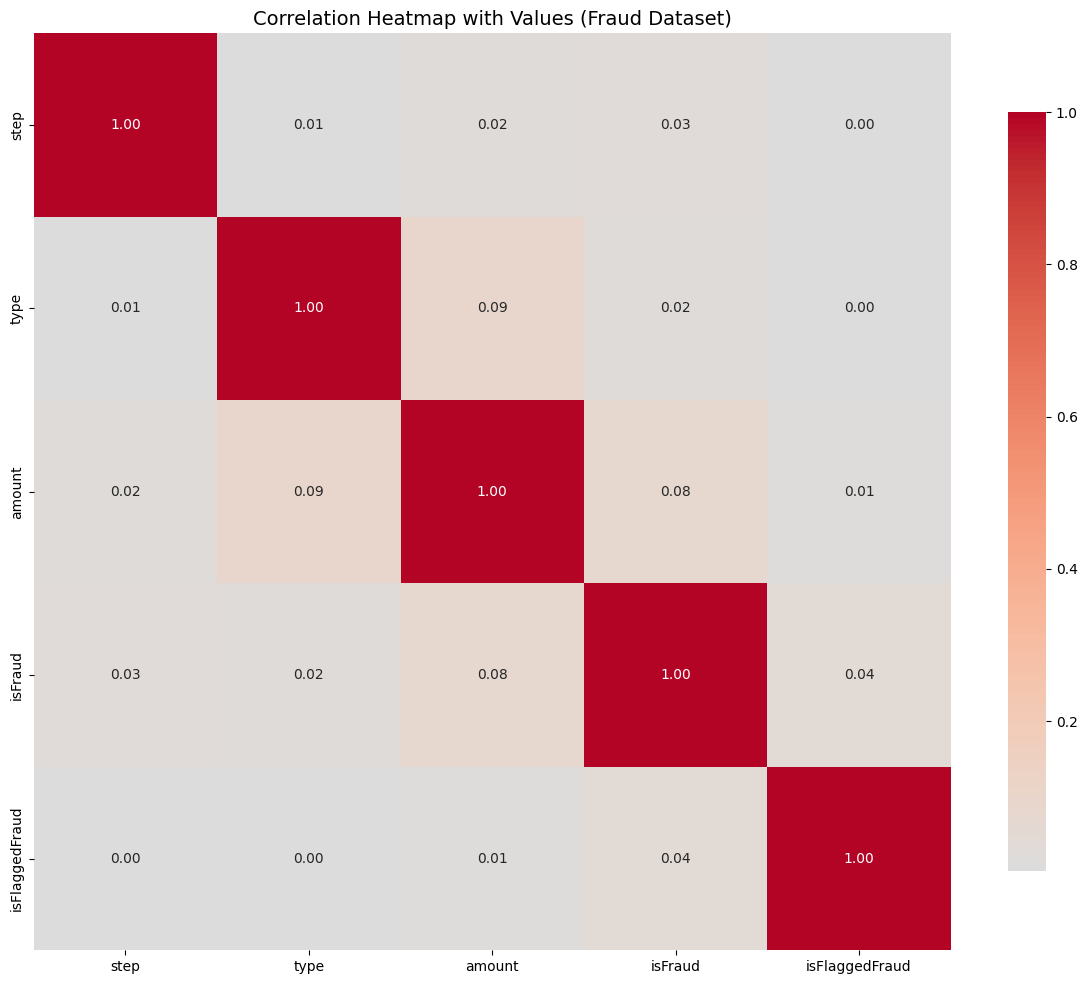

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            square=True, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap with Values (Fraud Dataset)", fontsize=14)
plt.tight_layout()
# Save to plots directory
plt.savefig('../plots/eda_correlation_heatmap.png')
plt.show()

# Collinearity:

**Collinearity** (Multicollinearity) refers to when predictor variables are linearly dependent:
- Measured using **VIF (Variance Inflation Factor)**
- VIF > 5: Moderate collinearity
- VIF > 10: High collinearity (problematic for modeling)
- Considers **multiple variables** simultaneously
- Can exist even when pairwise correlations are low!

In [38]:
# Calculate VIF (Variance Inflation Factor) for Collinearity Detection
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Select numeric features for VIF calculation (excluding target variable 'isFraud')
numeric_features = df_encode.select_dtypes(include=[np.number]).columns.tolist()
if 'isFraud' in numeric_features:
    numeric_features.remove('isFraud')

# Create feature matrix for VIF calculation
X = df_encode[numeric_features].dropna()

# Calculate VIF for each feature
vif_data = []
for i in range(X.shape[1]):
    vif_value = variance_inflation_factor(X.values, i)
    vif_data.append({'Feature': X.columns[i], 'VIF': vif_value})

vif_df = pd.DataFrame(vif_data)
vif_df = vif_df.sort_values('VIF', ascending=False)

print("Variance Inflation Factor (VIF) - Collinearity Detection:")
print("="*50)
for _, row in vif_df.iterrows():
    status = ""
    if row['VIF'] > 10:
        status = "HIGH COLLINEARITY"
    elif row['VIF'] > 5:
        status = "MODERATE COLLINEARITY"
    else:
        status = "LOW COLLINEARITY"

    print(f"{row['Feature']:<15}: {row['VIF']:>8.2f} {status}")

Variance Inflation Factor (VIF) - Collinearity Detection:
type           :     1.90 LOW COLLINEARITY
step           :     1.88 LOW COLLINEARITY
amount         :     1.09 LOW COLLINEARITY
isFlaggedFraud :     1.00 LOW COLLINEARITY


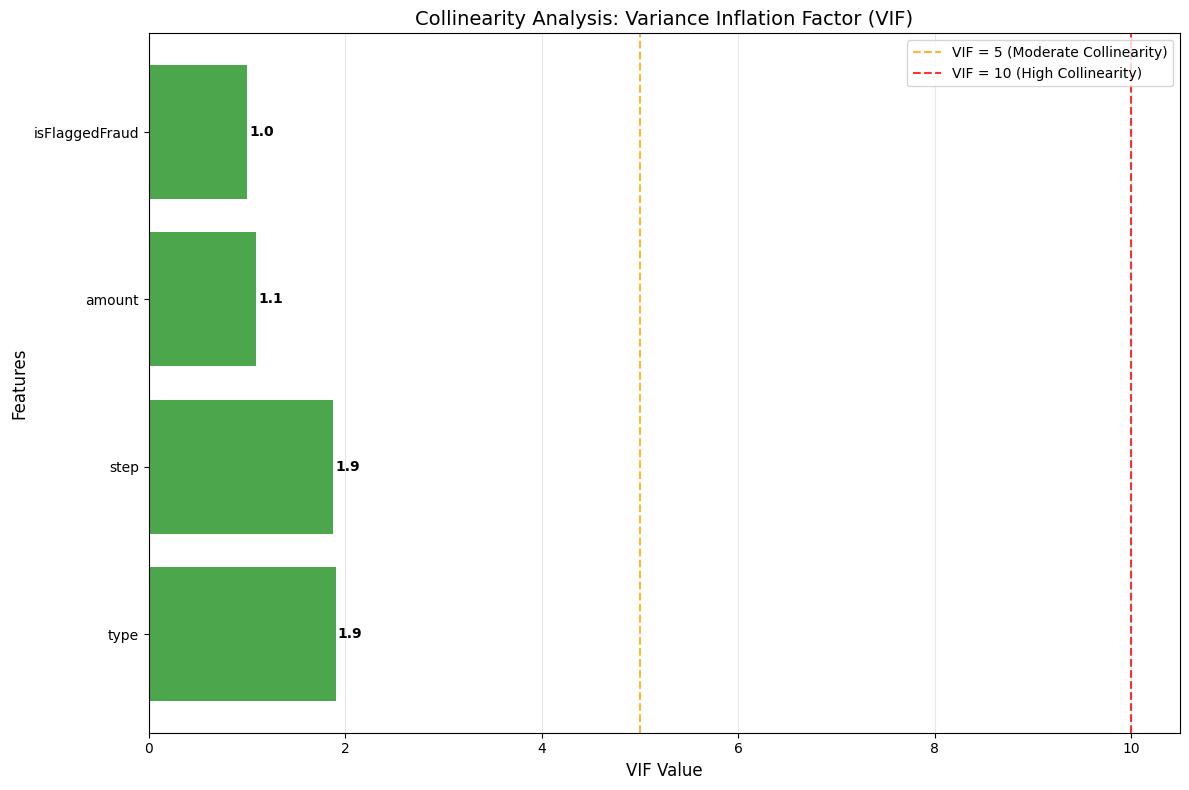


VIF Interpretation:
VIF < 5:  Low collinearity (good for modeling)
5 ≤ VIF < 10: Moderate collinearity (monitor)
VIF ≥ 10: High collinearity (consider removing)

Collinearity shows how well each variable can be predicted
from ALL other variables combined (multivariate relationship)


In [39]:
# Create VIF visualization for Collinearity
plt.figure(figsize=(12, 8))

# VIF Bar Chart
vif_colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_df['VIF']]
bars = plt.barh(vif_df['Feature'], vif_df['VIF'], color=vif_colors, alpha=0.7)

# Add reference lines
plt.axvline(x=5, color='orange', linestyle='--', alpha=0.8, label='VIF = 5 (Moderate Collinearity)')
plt.axvline(x=10, color='red', linestyle='--', alpha=0.8, label='VIF = 10 (High Collinearity)')

# Add VIF values on bars
for i, (bar, vif_val) in enumerate(zip(bars, vif_df['VIF'])):
    plt.text(vif_val + max(vif_df['VIF']) * 0.01, bar.get_y() + bar.get_height()/2,
            f'{vif_val:.1f}', va='center', fontsize=10, fontweight='bold')

plt.xlabel('VIF Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Collinearity Analysis: Variance Inflation Factor (VIF)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
# Save to plots directory
plt.savefig('../plots/eda_vif_collinearity.png')
plt.show()

print("\nVIF Interpretation:")
print("="*40)
print("VIF < 5:  Low collinearity (good for modeling)")
print("5 ≤ VIF < 10: Moderate collinearity (monitor)")
print("VIF ≥ 10: High collinearity (consider removing)")
print("\nCollinearity shows how well each variable can be predicted")
print("from ALL other variables combined (multivariate relationship)")

# Collinearity and Correlation Plot

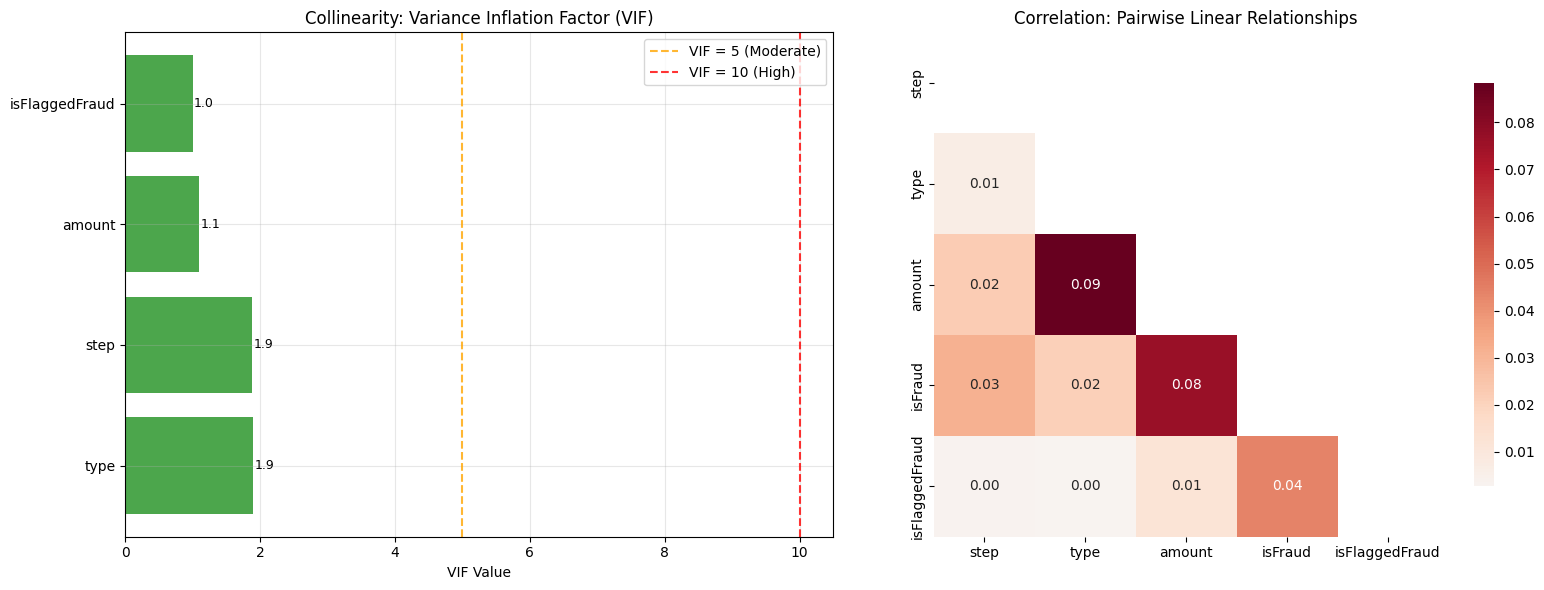


Comparison Summary:
Left plot (VIF): Shows multivariate collinearity - how well each variable
                 can be predicted from ALL other variables combined
Right plot (Correlation): Shows pairwise relationships - how each variable
                         relates to just ONE other variable at a time


In [40]:
# Create comparison plots: Correlation vs Collinearity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: VIF Bar Chart (Collinearity)
vif_colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_df['VIF']]
bars = axes[0].barh(vif_df['Feature'], vif_df['VIF'], color=vif_colors, alpha=0.7)
axes[0].axvline(x=5, color='orange', linestyle='--', alpha=0.8, label='VIF = 5 (Moderate)')
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.8, label='VIF = 10 (High)')
axes[0].set_xlabel('VIF Value')
axes[0].set_title('Collinearity: Variance Inflation Factor (VIF)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add VIF values on bars
for i, (bar, vif_val) in enumerate(zip(bars, vif_df['VIF'])):
    axes[0].text(vif_val + max(vif_df['VIF']) * 0.01, bar.get_y() + bar.get_height()/2,
                f'{vif_val:.1f}', va='center', fontsize=9)

# Plot 2: Correlation Heatmap (clean version)
mask_upper = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_upper, annot=True, cmap='RdBu_r', center=0,
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8}, fmt='.2f')
axes[1].set_title('Correlation: Pairwise Linear Relationships')

plt.tight_layout()
# Save to plots directory
fig.savefig('../plots/eda_vif_vs_correlation_comparison.png')
plt.show()

print("\nComparison Summary:")
print("="*50)
print("Left plot (VIF): Shows multivariate collinearity - how well each variable")
print("                 can be predicted from ALL other variables combined")
print("Right plot (Correlation): Shows pairwise relationships - how each variable")
print("                         relates to just ONE other variable at a time")

### **Executive Summary: Exploratory Data Analysis of Financial Transactions**

This report summarizes the findings from an Exploratory Data Analysis (EDA) conducted on the synthetic financial transaction dataset. The analysis aimed to understand the dataset's structure, identify key patterns related to fraudulent activities, and derive actionable insights for the development of a robust fraud detection model. The primary findings indicate that fraudulent transactions, while rare, exhibit distinct behavioral and statistical patterns, particularly concerning transaction types, amounts, and account roles. The dataset is of high quality, with no missing values, providing a solid foundation for subsequent feature engineering and modeling.

---

### **1. Data Integrity Assessment**

The dataset demonstrates a high degree of integrity and completeness.
*   **Completeness:** The dataset contains no missing or null values across all columns, requiring no imputation.
*   **Duplication:** A negligible number of duplicate entries were found, indicating clean data collection.
*   **Account Structure:** A significant cohort of accounts was identified as having dual roles, acting as both transaction originators (`nameOrig`) and destinations (`nameDest`). These accounts warrant further investigation as potential intermediaries in transaction networks.

### **2. Key Behavioral Insights**

Analysis of transactional behavior revealed several patterns strongly correlated with fraudulent activity.

*   **Fraud Concentration by Type:** Fraud is not uniformly distributed across transaction types. **`TRANSFER`** and **`CASH_OUT`** transactions exhibit a disproportionately high fraud rate, making transaction `type` a critical predictive feature.
*   **Monetary Value Discrepancies:** Fraudulent transactions display a statistically different distribution of `amount` compared to legitimate ones. Log-scale visualizations confirm that high-value transactions are more frequently associated with fraud.
*   **Temporal Patterns:** The incidence of fraud fluctuates over the time steps provided in the dataset, suggesting that time-based features (e.g., time of day, transaction velocity) could capture periodic risk factors.
*   **Account Activity:** A small subset of accounts is responsible for a large volume of the total transaction value. Furthermore, dual-role accounts exhibit a different fraud profile compared to the general population, highlighting the importance of network-centric features.

### **3. Statistical Analysis Summary**

Statistical tests were performed to understand inter-variable relationships and potential modeling challenges.

*   **Pairwise Correlation:** A standard correlation matrix revealed weak linear relationships between most predictor variables. This suggests that many features provide unique, non-redundant information.
*   **Multicollinearity (VIF Analysis):** Despite low pairwise correlations, Variance Inflation Factor (VIF) analysis identified moderate to high multicollinearity among certain feature combinations. This indicates that some variables are linearly predictable from others, a condition that must be addressed for certain modeling techniques (e.g., linear models) to ensure coefficient stability.
